[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bsheese/225/blob/main/07_data_vis/07_3_Comparing_Categories.ipynb)

# 07.3: Comparing Categories

The Titanic data has several categorical variables: passenger class (1st, 2nd, 3rd), sex (male, female), and survival status. The questions that matter most are about how these categories relate to each other and to numeric variables like fare and age.

This notebook covers the chart types built specifically for categorical data: count plots, bar plots that show summary statistics, and grouped versions of the box and violin charts you already know.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")

df = sns.load_dataset("titanic")
df = df[["survived", "pclass", "sex", "age", "sibsp", "parch", "fare"]].copy()
df.head()

,survived,pclass,sex,age,sibsp,parch,fare
0,0,3,male,22.0,1,0,7.2500
1,1,1,female,38.0,1,0,71.2833
2,1,3,female,26.0,0,0,7.9250
3,1,1,female,35.0,1,0,53.1000
4,0,3,male,35.0,0,0,8.0500


## How many passengers were in each class?

Before asking anything about survival, it helps to know the basic composition of the dataset. The simplest categorical chart is the **count plot**: one bar per category, height equals number of observations.

Text(0, 0.5, 'Count')

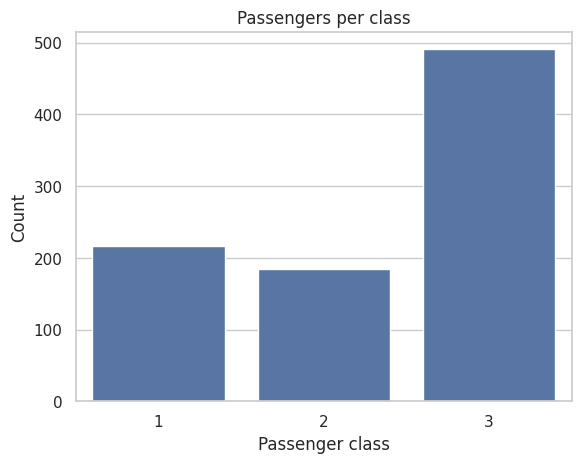

In [2]:
ax = sns.countplot(data=df, x="pclass", order=[1, 2, 3])
ax.set_title("Passengers per class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Count")

Third class carried more passengers than first and second class combined. This imbalance is important context for any survival comparison: if survival rates are similar across classes, the absolute number of third-class deaths will still be much higher simply because there were more third-class passengers.

The `order=` parameter forces the bars into the sequence you specify. Without it, seaborn uses the order the categories appear in the data, which is often arbitrary. Always be explicit about ordering when the categories have a natural sequence.

Adding a second categorical variable with `hue=` splits each bar by an additional grouping.

Text(0, 0.5, 'Count')

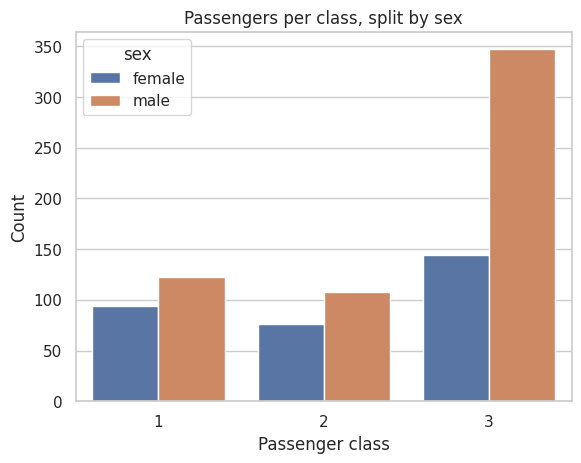

In [3]:
ax = sns.countplot(data=df, x="pclass", hue="sex", order=[1, 2, 3])
ax.set_title("Passengers per class, split by sex")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Count")

First class was nearly gender-balanced. Third class had nearly twice as many men as women. This is not a trivial detail: since women survived at much higher rates, the gender imbalance within third class further suppressed that class's overall survival rate.

## Survival rates by category

A count plot just shows how many. The more interesting question is usually how a numeric variable (like survival) differs across categories. `sns.barplot()` computes an aggregate statistic (the mean, by default) for each category and displays it as a bar, with a confidence interval shown as an error bar.

Because `survived` is coded as 0 and 1, its mean is the proportion who survived. This makes `sns.barplot()` a direct way to visualize survival rates.

(0.0, 1.0)

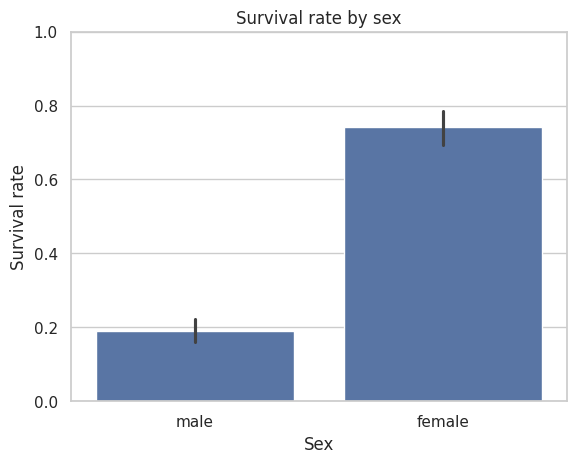

In [4]:
ax = sns.barplot(data=df, x="sex", y="survived", errorbar="ci")
ax.set_title("Survival rate by sex")
ax.set_xlabel("Sex")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

The bars show the mean of `survived` for each group, which equals the fraction who survived. The thin vertical lines at the top of each bar are 95% confidence intervals: they show the range of plausible values for the true survival rate given the data. Female passengers survived at about 74%; male passengers at about 19%.

Now let's add class as a second variable.

(0.0, 1.0)

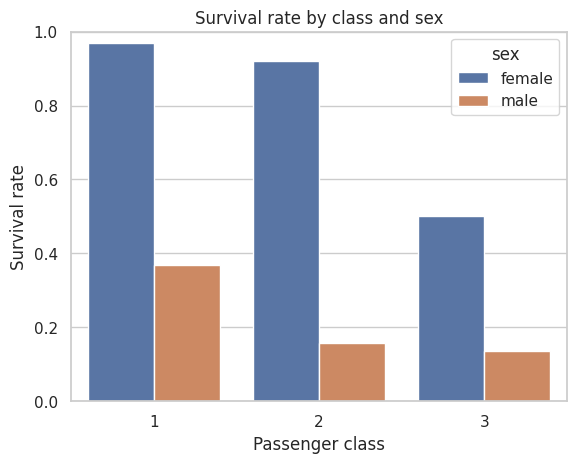

In [5]:
ax = sns.barplot(
    data=df, x="pclass", y="survived",
    hue="sex",
    order=[1, 2, 3],
    errorbar=None
)
ax.set_title("Survival rate by class and sex")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Survival rate")
ax.set_ylim(0, 1)

This table in visual form tells you more than any single number could. First-class women survived at nearly 97%. Third-class men survived at under 14%. Being female was the strongest factor, but class still mattered enormously within each sex.

Notice that this is exactly the same information as the `groupby` result from module 06:
```python
df.groupby(["pclass", "sex"])["survived"].mean()
```
The chart does not compute anything new. It just makes the pattern visible at a glance. This is the connection the TODO.md plan mentioned: every categorical bar chart is a grouped aggregation drawn instead of printed.

## How does fare vary across classes?

Bar plots work well when the y variable is a proportion or a mean you care about directly. When you want to understand the full spread of a numeric variable across categories, a box plot is more informative.

Text(0, 0.5, 'Fare (pounds)')

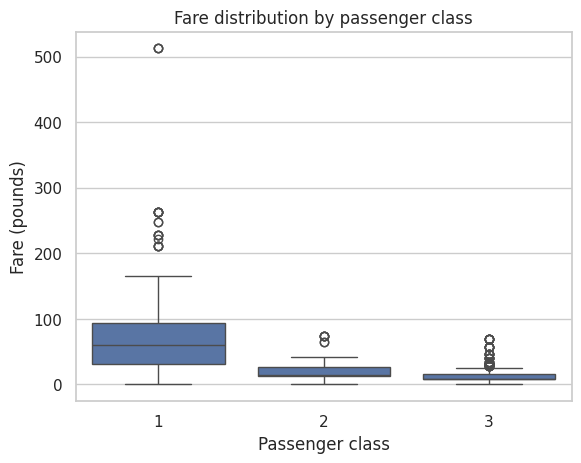

In [6]:
ax = sns.boxplot(data=df, x="pclass", y="fare", order=[1, 2, 3])
ax.set_title("Fare distribution by passenger class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Fare (pounds)")

The first-class box is tall (wide interquartile range) and sits high on the y-axis. But the many outlier dots above the whisker show that even within first class there was huge variation in fare. The third-class box is narrow and low, sitting below 15 pounds, with a few outliers above.

The outlier dots are obscuring the structure a bit. Two adjustments help: hiding the outliers and applying a log scale to the y-axis.

Text(0, 0.5, 'Fare (pounds, log scale)')

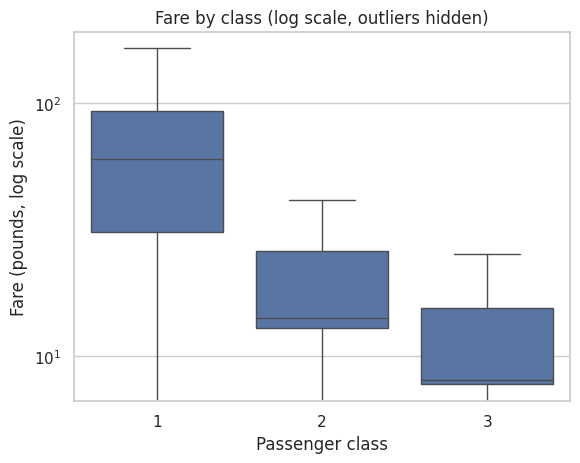

In [7]:
ax = sns.boxplot(
    data=df, x="pclass", y="fare",
    order=[1, 2, 3],
    showfliers=False
)
ax.set_yscale("log")
ax.set_title("Fare by class (log scale, outliers hidden)")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Fare (pounds, log scale)")

With the outliers hidden and the y-axis logged, the three boxes are more comparable. The interquartile ranges within each class are clearly distinct, and the medians (horizontal lines) confirm the class ordering: first class paid the most at the median, third class the least.

## Seeing the full shape: violin and strip plots

A box plot summarizes each group in five numbers. If you want to see the full shape of each group's distribution, a violin plot shows the KDE on both sides of a center axis.

Text(0, 0.5, 'Age')

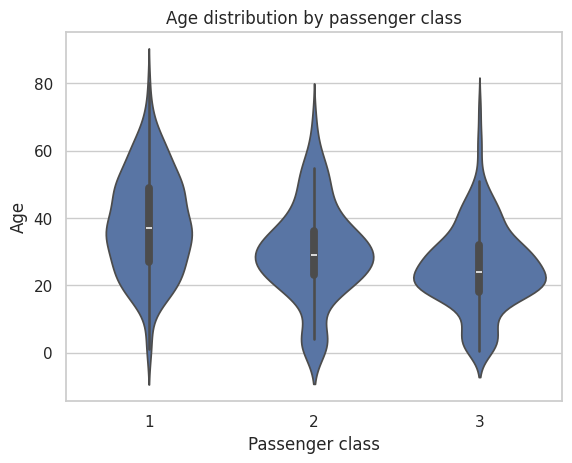

In [8]:
ax = sns.violinplot(
    data=df, x="pclass", y="age",
    order=[1, 2, 3],
    inner="box"
)
ax.set_title("Age distribution by passenger class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Age")

First-class passengers were older on average: the violin is wider in the 30 to 60 range. Third-class passengers were younger: the violin bulges more in the 20s and has a visible bump near zero from young children. Second class falls between the two.

When your dataset is small enough that showing individual points is practical, `sns.stripplot()` plots every observation as a dot. This avoids the KDE's smoothing assumption and shows the actual data.

Text(0, 0.5, 'Age')

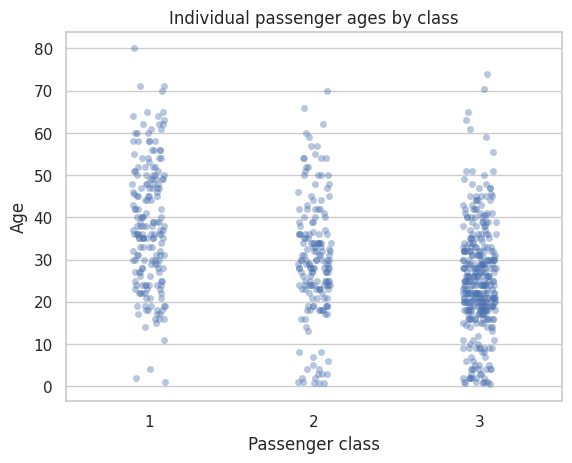

In [9]:
ax = sns.stripplot(
    data=df, x="pclass", y="age",
    order=[1, 2, 3],
    alpha=0.4, jitter=True
)
ax.set_title("Individual passenger ages by class")
ax.set_xlabel("Passenger class")
ax.set_ylabel("Age")

With 891 points, the strip plot is crowded but still readable. The `jitter=True` parameter adds a small horizontal wobble so that overlapping points separate slightly. You can see the young children in all three classes (dots near zero) and the relative scarcity of elderly passengers in third class.

For even larger datasets, `sns.swarmplot()` arranges the points so they do not overlap at all, though it becomes slow above a few thousand points.

## Ordering categories deliberately

A chart with unordered categorical bars is often harder to read than it needs to be. Seaborn defaults to the order the categories appear in the data, which is usually arbitrary. You can override this with `order=` and `hue_order=`.

For categories with no natural order (like port of embarkation, or a list of cities), a common convention is to sort by the value being displayed, so the eye can quickly find the highest and lowest bars.

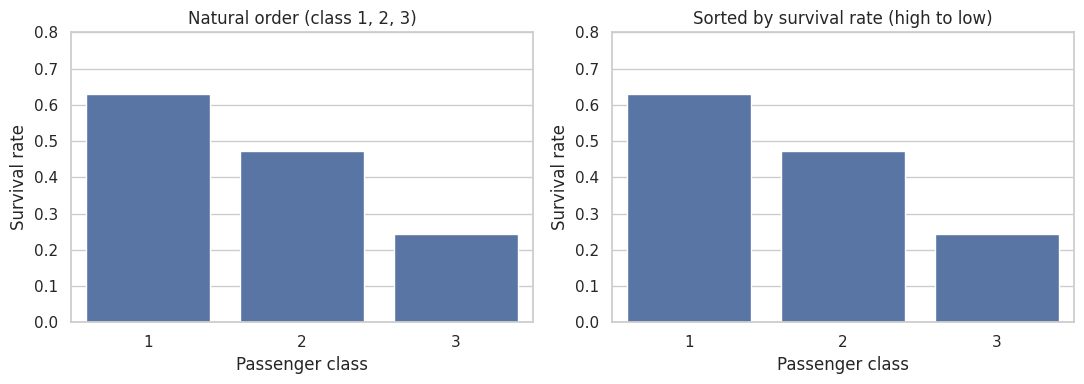

In [10]:
# Compute survival rate per class to determine sort order
class_order = (
    df.groupby("pclass")["survived"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=df, x="pclass", y="survived", order=[1,2,3],
            errorbar=None, ax=axes[0])
axes[0].set_title("Natural order (class 1, 2, 3)")
axes[0].set_xlabel("Passenger class")
axes[0].set_ylabel("Survival rate")
axes[0].set_ylim(0, 0.8)

sns.barplot(data=df, x="pclass", y="survived", order=class_order,
            errorbar=None, ax=axes[1])
axes[1].set_title("Sorted by survival rate (high to low)")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("Survival rate")
axes[1].set_ylim(0, 0.8)

plt.tight_layout()

Both charts show the same data. The sorted version makes the ranking immediately obvious: you can read the ordering from left to right without scanning across bars of different heights. For class data, the natural order (1, 2, 3) is actually meaningful and fine to keep. For arbitrary categories, sorting by value is almost always the better choice.

## What's next

You can now compare categories using counts, summary statistics, distributions, and individual points. All of these charts have one thing in common: one axis is categorical. In 07.4 we put two numeric variables on the axes and ask how they relate to each other.